In [10]:
from geostat_isoscapes_tools import utils, sisal_utils, geostat_utils
import numpy as np
from pykrige.uk import UniversalKriging
from scipy.interpolate import RegularGridInterpolator
import pandas as pd
import json
from scipy.interpolate import griddata

import seaborn as sns

sns.set_style('dark')

Load SISAL data and prepare it for kriging

In [2]:
# load calcite data, sanatize it, convert to drip water equivalents, take a temporal sclice.

# define which chronology to use
def get_sisal_data_for_kriging(chrono:str = 'interp_age',res : int = 200, temp_ds_fn :str = '../data/temperature/temp_800ka_ann.nc',country='China',buffer_km=500):
    """ Load SISAL data, sanatize it, convert it to drip water equivalents, sclice at the desired temporal resolution ."""
    data_df = sisal_utils.get_basic_cleaned_merged_sisal_data(chrono=chrono)

    # load temperature dataset
    temp_xda = utils.load_xarray_datarray(temp_ds_fn).temp

    # compute converted data
    data_df_drip_water = sisal_utils.retrieve_temperature_and_convert_speleothem_d18O(data_df,chrono=chrono,temp_xda=temp_xda,method='linear')
    # remove samples for which the conversion failed (usually due to T retrieval failure)
    data_df_drip_water = data_df_drip_water.dropna(subset='d18Op_VSMOW')

    # Bin years to the desired temporal resolution
    chrono_series = data_df_drip_water['interp_age'].copy()
    data_df_drip_water['binned_interp_age'] = utils.slice_in_equal_bins(chrono_series,res)

    data_df_drip_water = data_df_drip_water.rename(columns={'latitude':'lat','longitude':'lon'})

    data_ready = utils.mask_country_shape(data_df_drip_water,buffer_km=buffer_km)

    data_ready = data_ready.rename(columns={'lat':'latitude','lon':'longitude'}) # type:ignore

    return data_ready

chrono = 'interp_age'
data_with_time_slices = get_sisal_data_for_kriging(chrono)


-> loading database
   cleaning samples
loading and cleaning done.
-> converting speleothem data
   linear interpolation failed for 76882 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 19026 samples.
   temperature retrieval finished, starting conversion
   for mineralogy calcite, the conversion failed for 19026 samples.
   for mineralogy aragonite, the conversion failed for 0 samples.
conversion done.


Select a time slice and visualize data to krige  

In [3]:
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_interp_age']==10800)].dropna(subset='d18Op_VSMOW')
sisal_utils.plot_global_map(data_to_krige,'data to krige','d18Op_VSMOW') # type:ignore

Load modern data and prepare it for being the external drift 

In [4]:
def get_itracedata_for_external_drift():
    # load files 
    fn_itrace_H218O = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H218O.800001-899912.nc'
    fn_itrace_H2OTR = '../data/modern/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H2OTR.800001-899912.nc'
    file_H218O = utils.load_xarray_datarray(fn_itrace_H218O)
    file_H2OTR = utils.load_xarray_datarray(fn_itrace_H2OTR)
    # compute the delta18Op
    h218o = file_H218O.RAIN_H218O
    h2o = file_H2OTR.RAIN_H2OTR
    delta18 = ( h218o/h2o - 1.0) * 1000.0
    delta18 = delta18.where((h2o > 1e-12)&(delta18 < 1e2))  # avoid div by near-0 precip values and positive outliers (delta18 should be mostly negative and small -20/+20)
    # make the temporal resolution regular 
    time_series = pd.Series(delta18.time.values)
    maxres = time_series.sort_values().diff().max()
    print(f'-> regular temporal resolution of {maxres} days')
    tmin, tmax = float(delta18.time.min()), float(delta18.time.max())
    bins = np.arange(tmin, tmax + int(maxres), int(maxres)) #type:ignore

    da_binned = delta18.groupby_bins('time', bins=bins).mean()
    da_binned = da_binned.rename({'time_bins': 'time'})
    delta18_binned = da_binned.assign_coords(time=bins[:-1])

    china_da_binned = utils.mask_country_shape(delta18_binned,buffer_km=1000)
    
    china_df = china_da_binned.to_dataframe(name='d18Op').reset_index().dropna() # type:ignore
    china_df = china_df.rename(columns={'lon':'longitude','lat':'latitude'})
    return china_df

itrace_data = get_itracedata_for_external_drift()


-> regular temporal resolution of 31.0 days


In [5]:
# number of time steps 
itrace_times = itrace_data['time'].unique()
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-5]].dropna()

sisal_utils.plot_global_map(external_drift_df,'external drift','d18Op') # type:ignore

Retrieve the variogram model and parameters (of itrace)

In [6]:
with open('../output/variograms/global_variogram_model_dict_itrace.json', 'r') as f:
    variogram_dict = json.load(f)

print(variogram_dict)

{'sill': 9.563353132550434, 'range': 2089488.262858711, 'nugget': 0.873555537101984, 'model_name': 'spherical'}


In [ ]:
# Setup for the kriging
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['longitude'].values,data_to_krige['latitude'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['longitude'].values,external_drift_df['latitude'].values)

df_exp = data_to_krige
df_drift = external_drift_df

# Define grid in Mercator space, covering all SISAL points
nx, ny = 200, 200  # grid resolution (adjust as needed)
x_grid = np.linspace(df_drift["x"].min()-100000, df_drift["x"].max()+100000, nx)
y_grid = np.linspace(df_drift["y"].min()-100000, df_drift["y"].max()+100000, ny)
xv, yv = np.meshgrid(x_grid, y_grid)

# Interpolate the drift on the Mercator grid (-> drift grid)
drift_grid = griddata(
    points=(df_drift["x"], df_drift["y"]),
    values=df_drift["d18Op"].values,
    xi=(xv, yv),
    method="linear"
)

# For each SISAL data point, assign corresponding drift value (-> drift points)
drift_points = griddata(
    points=(df_drift["x"], df_drift["y"]),
    values=df_drift["d18Op"],
    xi=(df_exp["x"], df_exp["y"]),
    method="linear"
)

# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}

In [ ]:
# KED kriging object

uk = UniversalKriging(
    x=df_exp["x"],
    y=df_exp["y"],
    z=df_exp["d18Op_VSMOW"],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[drift_points]
)

z_pred, ss_pred = uk.execute(
    style="grid",
    xpoints=x_grid,
    ypoints=y_grid,
    specified_drift_arrays=[drift_grid]
)

**Plot the results**

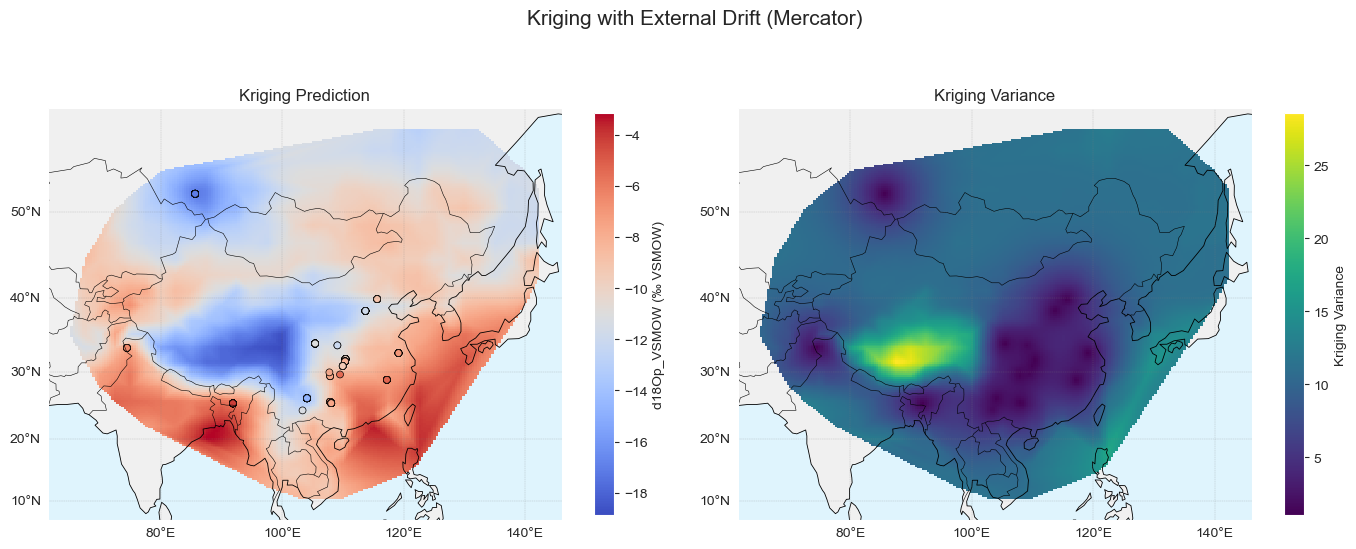

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_ked_mercator(
    x_grid, y_grid, z_pred, ss_pred,
    df_exp, value_col='d18Op_VSMOW',
    lon_exp=None, lat_exp=None,  # optional lon/lat for labels
    title="Kriging with External Drift (Mercator)",
    cmap="coolwarm",
    figsize=(14,6),
    vmin=None, vmax=None
):
    """
    Plot KED kriging results in Mercator projection with variance map
    and overlay experimental points.
    
    Parameters
    ----------
    x_grid, y_grid : 1D arrays for grid coordinates in meters (Mercator)
    z_pred : 2D array of kriging predictions
    ss_pred : 2D array of kriging variances
    df_exp : DataFrame of experimental points, must contain value_col
    value_col : column in df_exp to use for coloring points
    lon_exp, lat_exp : optional, for display (not needed for projection)
    """
    
    fig, axes = plt.subplots(
        1, 2, figsize=figsize,
        subplot_kw={'projection': ccrs.Mercator()}
    )
    
    # Set extent in Mercator coordinates
    for ax in axes:
        ax.set_extent([
            x_grid.min()-300000, x_grid.max()+300000,
            y_grid.min()-300000, y_grid.max()+300000
        ], crs=ccrs.Mercator())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", edgecolor="none")
        ax.add_feature(cfeature.OCEAN, facecolor="#dff4fd", edgecolor="none")
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
        gl.right_labels = gl.top_labels = False
    
    # Create meshgrid for pcolormesh
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # Left: KED predictions
    mesh = axes[0].pcolormesh(
        X, Y, z_pred,
        transform=ccrs.Mercator(),
        shading='auto',
        cmap=cmap,
        vmin=vmin if vmin is not None else np.nanmin(z_pred),
        vmax=vmax if vmax is not None else np.nanmax(z_pred)
    )
    
    # Overlay experimental points
    axes[0].scatter(
        df_exp['x'], df_exp['y'],
        c=df_exp[value_col],
        s=25,
        edgecolor='black',
        linewidth=0.5,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.Mercator()
    )
    
    cbar = plt.colorbar(mesh, ax=axes[0], orientation='vertical', shrink=0.75, pad=0.05)
    cbar.set_label(f"{value_col} (‰ VSMOW)")
    axes[0].set_title("Kriging Prediction")
    
    # Right: Kriging variance
    mesh2 = axes[1].pcolormesh(
        X, Y, ss_pred,
        transform=ccrs.Mercator(),
        shading='auto',
        cmap='viridis'
    )
    cbar2 = plt.colorbar(mesh2, ax=axes[1], orientation='vertical', shrink=0.75, pad=0.05)
    cbar2.set_label("Kriging Variance")
    axes[1].set_title("Kriging Variance")
    
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


plot_ked_mercator(
    x_grid=x_grid,
    y_grid=y_grid,
    z_pred=z_pred,
    ss_pred=ss_pred,
    df_exp=df_exp,
    value_col='d18Op_VSMOW',
    cmap="coolwarm"
)